# Denoising Biomedical Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Electrocardiogram dataset - EKG

In [14]:
from google.colab import files
uploaded = files.upload()


Saving medical_data.csv to medical_data.csv


In [16]:
df = pd.read_csv('medical_data.csv', sep=',',names=['noisy','orig'])

In [17]:
df

,noisy,orig
0,920.23,963
1,929.06,987
2,1116.60,1024
3,1073.60,1073
4,1070.60,1134
...,...,...
995,953.24,1020
996,913.34,1020
997,961.08,1025
998,953.80,1030


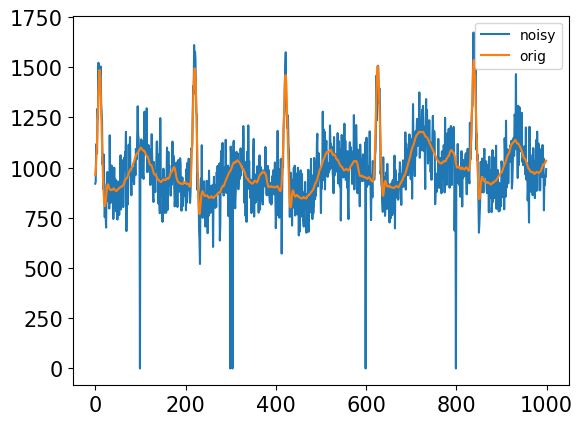

In [20]:
df.plot(fontsize=15)
plt.show()

In [21]:
df['filtered'] = df['noisy'].copy()
df

,noisy,orig,filtered
0,920.23,963,920.23
1,929.06,987,929.06
2,1116.60,1024,1116.60
3,1073.60,1073,1073.60
4,1070.60,1134,1070.60
...,...,...,...
995,953.24,1020,953.24
996,913.34,1020,913.34
997,961.08,1025,961.08
998,953.80,1030,953.80


In [23]:
from re import sub
# Median filter for small values
threshold = 321

# find subthreshold data indices
subthreshold_indices = np.where(df['filtered'] < threshold)[0]

# apply the median filter
k = 7
for i in subthreshold_indices:
  df['filtered'][i] = np.median(df['filtered'][np.max((0,i-k)):np.min((len(df),i+k))])


/tmp/ipykernel_2057/2701983801.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['filtered'][i] = np.median(df['filtered'][np.max((0,i-k)):np.min((len(df),i+k))])
/tmp/ipykernel_2057/2701983801.py:11: SettingWithCopyWarning: 
A value i

<Axes: >

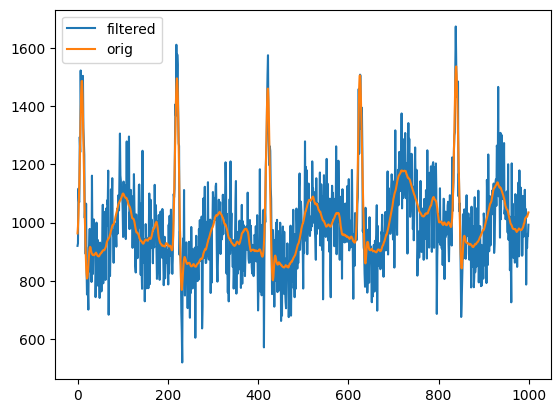

In [24]:
df[['filtered','orig']].plot()

In [26]:
# apply the mean filter
k = 7
for i in range(len(df)):
  df['filtered'][i] = np.mean(df['filtered'][np.max((0,i-k)):np.min((len(df),i+k))])


/tmp/ipykernel_2057/1517059812.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['filtered'][i] = np.mean(df['filtered'][np.max((0,i-k)):np.min((len(df),i+k))])
/tmp/ipykernel_2057/1517059812.py:4: SettingWithCopyWarning: 
A value is tr

<Axes: >

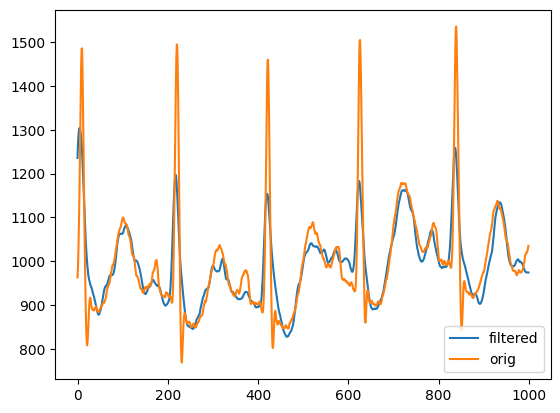

In [27]:
df[['filtered','orig']].plot()